**Programmer:** python_scripts (Abhijith Warrier)

**PYTHON SCRIPT TO SIMULATE A CANARY DEPLOYMENT WHERE A NEW ML MODEL IS GRADUALLY ROLLED OUT TO A SMALL PERCENTAGE OF USERS. ⚡️🐤🚀**

Deploying a new machine learning model directly to all users can be risky. Instead, organizations often use **Canary Deployment**, where a small percentage of traffic is routed to the new model while the majority continues using the existing production model.

In this project, we’ll simulate a canary deployment strategy and compare the performance of both models before deciding whether to increase the rollout.

---

## **📦 Import Required Libraries**

In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score
)

---

## **🧩 Load Dataset**

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = data.target

---

## **✂️ Split Dataset**

In [4]:
X_train, X_live, y_train, y_live = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = data.target

Here, `X_live` represents incoming production requests.

---

## **🤖 Train Production Model**

In [5]:
production_model = LogisticRegression(
    max_iter=5000
)

production_model.fit(
    X_train,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


---

## **🚀 Train Canary Model**

In [6]:
canary_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

canary_model.fit(
    X_train,
    y_train
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


---

## **🐤 Split Traffic**

Assume:

- **90%** → Production model
- **10%** → Canary model

In [7]:
traffic_percentage = 0.10

canary_size = int(
    len(X_live) *
    traffic_percentage
)

production_size = (
    len(X_live) -
    canary_size
)

---

## **🚦 Route Requests**

In [8]:
X_prod = X_live.iloc[:production_size]
y_prod = y_live[:production_size]

X_canary = X_live.iloc[production_size:]
y_canary = y_live[production_size:]

---

## **📊 Generate Predictions**

In [9]:
prod_predictions = production_model.predict(
    X_prod
)

canary_predictions = canary_model.predict(
    X_canary
)

---

## **📈 Evaluate Both Models**

In [10]:
prod_accuracy = accuracy_score(
    y_prod,
    prod_predictions
)

canary_accuracy = accuracy_score(
    y_canary,
    canary_predictions
)

print("Production Accuracy:", prod_accuracy)
print("Canary Accuracy:", canary_accuracy)

Production Accuracy: 0.9415584415584416
Canary Accuracy: 0.8823529411764706


---

## **📋 Deployment Decision**

In [13]:
if canary_accuracy >= prod_accuracy:
    print("🚀 Increase Canary Traffic")
else:
    print("⛔ Roll Back Canary Deployment")

⛔ Roll Back Canary Deployment


---

## **📊 Visualize Rollout**

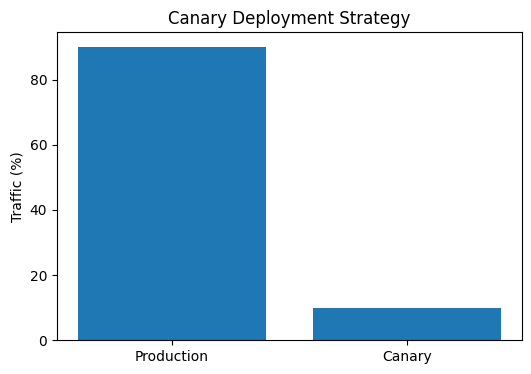

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    ["Production", "Canary"],
    [90, 10]
)

plt.ylabel("Traffic (%)")
plt.title("Canary Deployment Strategy")

plt.show()

---

## **🌍 How Canary Deployment Works**

Unlike Shadow Deployment:

```jsx
100% → Production

100% → Shadow (Hidden)
```

Canary Deployment exposes the new model to **real users**.

Example:

```jsx
90% → Production Model

10% → Canary Model
```

If the new model performs well:

```jsx
75% → Production

25% → Canary
```

Eventually:

```jsx
100% → Canary Model
```

The old model is retired.

---

## **🧠 Benefits of Canary Deployment**

- safer production releases
- gradual rollout
- early failure detection
- easy rollback
- reduced business risk

---

## **🧠 Key Takeaways**

1. Canary deployment gradually exposes users to a new model.
2. Only a small percentage of traffic is routed initially.
3. Model performance is monitored before increasing rollout.
4. Poor-performing models can be rolled back immediately.
5. Canary deployment is a widely used strategy in production ML systems.

---

## **Conclusion**

Canary deployment provides a safe and controlled way to introduce new machine learning models into production. By gradually increasing traffic only after validating real-world performance, organizations reduce deployment risk while maintaining service reliability.

This continues the **ML Systems Advanced** track in **Saturday ML Spark ⚡️**, exploring production deployment strategies used by modern machine learning teams.

---